ANÁLISE DA BASE DE DADOS UNIFICADA
_______________________________________________________________________________________________________________________


In [2]:
# importando as bibliotecas necessárias para a exploração e visualização de dados
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

# importando a base de dados diretamente do GitHub - repositório "mini_projeto_bps"
caminho_unificado = '../dados/BPS_20_26_MariaHelena.csv'

# transformando as bases de dados em dataframes
df_unificado = pd.read_csv(caminho_unificado, sep=';', encoding='utf-8')

# formatação para exibir os dataframes de forma mais legível
pd.set_option('display.width', None)          
pd.set_option('display.max_columns', None)    
pd.set_option('display.expand_frame_repr', False)

# verificando se os dados foram corretamente carregados
print(f"O Dataframe foi carregado com sucesso.")


O Dataframe foi carregado com sucesso.


ANÁLISE PRIMÁRIA DOS DADOS
_______________________________________________________________________________________________________________________

In [3]:
# verificando as informações gerais sobre a base de dados unificada
print('\nINFORMAÇÕES GERAIS SOBRE A BASE DE DADOS UNIFICADA\n')


# verificando o número de linhas e colunas do df_unificado
print('=========== DIMENSÕES DA BASE DE DADOS ==========')
print(f'\nBase carregada com {df_unificado.shape[0]} linhas e {len(df_unificado.columns)} colunas.')                    

# verificando as primeiras e as últimas 10 linhas do dataframe
print('\n========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========')
print(f'\nInformações sobre as primeiras 10 linhas: \n{df_unificado.head(10).to_string()}')                     
print(f'\nInformações sobre as últimas 10 linhas: \n{df_unificado.tail(10).to_string()}')                       

# verificando as informações gerais sobre o dataframe
print('\n========== INFORMAÇÕES GERAIS ==========')
print(f'\nInformações gerais sobre os dados:')                                                      
print(df_unificado.info())

# verificando a distribuição de valores únicos por coluna
print('\n========== INFORMAÇÕES SOBRE COLUNAS ==========')
print(f'\nVerificando a distribuição de valores únicos por coluna: \n{df_unificado.nunique().to_string()}')   
 
# verificando a existência de valores duplicados no dataframe
print('\n========== INFORMAÇÕES SOBRE VALORES DUPLICADOS ==========')
print(f'\nVerificando duplicatas: {df_unificado.duplicated().sum()}')                                         
 


INFORMAÇÕES GERAIS SOBRE A BASE DE DADOS UNIFICADA

=========== DIMENSÕES DA BASE DE DADOS ==========

Base carregada com 342716 linhas e 25 colunas.

========== ANALISANDO AS PRIMEIRAS E ÚLTIMAS LINHAS DOS DADOS ==========

Informações sobre as primeiras 10 linhas: 
   ano_compra                                     nome_instituicao     esfera    cnpj_instituicao municipio_instituicao  uf      compra    insercao  codigo_br                                                                                                                                                                                                                                                 descricao_catmat unidade_fornecimento generico        anvisa modalidade_compra     tipo_compra  capacidade unidade_medida unidade_fornecimento_capacidade     cnpj_fornecedor                                           fornecedor     cnpj_fabricante                                                 fabricante  qtd_itens_comprados  prec

ANÁLISE ESTATÍSTICA DESCRITIVA
_______________________________________________________________________________________________________________________

In [4]:
# estatística descritiva das colunas 'qtd_itens_comprados', 'preco_unitario' e 'preco_total'

colunas_estatisticas = [
    'qtd_itens_comprados',
    'preco_unitario',
    'preco_total'
]

# exibindo as estatísticas descritivas
print("\n===== Estatísticas descritivas das variáveis numéricas: =====\n")
print(df_unificado[colunas_estatisticas].describe().map('{:.2f}'.format))



===== Estatísticas descritivas das variáveis numéricas: =====

      qtd_itens_comprados preco_unitario     preco_total
count           342716.00      342716.00       342716.00
mean            166705.51         171.29       229223.85
std            8307963.60       17534.62     39847416.89
min                  1.00           0.00            0.00
25%                250.00           0.35          700.00
50%               1600.00           1.85         2800.00
75%              12000.00           7.17        13000.00
max         4356140000.00     8191720.00  22816000000.00


TRATAMENTO DOS DADOS
_________________________________________________________________________________________________________________________________________________________________________________

In [5]:
# TRANSFORMAÇÃO DE DADOS:

# transformando as colunas 'compra' e 'insercao' para o tipo datetime 
df_unificado['compra'] = pd.to_datetime(df_unificado['compra'], format='%d/%m/%Y', errors='coerce')
df_unificado['insercao'] = pd.to_datetime(df_unificado['insercao'], format='%d/%m/%Y', errors='coerce')

# convertendo a coluna 'anvisa' para string
df_unificado['anvisa'] = df_unificado['anvisa'].astype('Int64').astype(str)


In [6]:
# REMOÇÃO DAS DUPLICATAS:

# verificando as duplicadas:
duplicadas = df_unificado[df_unificado.duplicated(keep=False)]
duplicadas.sort_values(by=list(df_unificado.columns)).head(20)

,ano_compra,nome_instituicao,esfera,cnpj_instituicao,municipio_instituicao,uf,compra,insercao,codigo_br,descricao_catmat,unidade_fornecimento,generico,anvisa,modalidade_compra,tipo_compra,capacidade,unidade_medida,unidade_fornecimento_capacidade,cnpj_fornecedor,fornecedor,cnpj_fabricante,fabricante,qtd_itens_comprados,preco_unitario,preco_total
296883,2024,FUNDO MUNICIPAL DE SAUDE,MUNICIPAL,11.216.262/0001-04,VASSOURAS,RJ,2024-04-30,2024-08-21,337468,"DESLORATADINA, CONCENTRAÇÃO:0,5 MG/ML, FORMA F...",FRASCO,S,1058308200176,Dispensa de Licitação,JUDICIAL,100.0,ML,FRASCO 100.00 ML,28.843.779/0001-26,DROGARIA SANTA ALICE DE VASSOURAS LTDA,45.992.062/0001-65,GERMED FARMACEUTICA LTDA,1,13.92,13.92
296886,2024,FUNDO MUNICIPAL DE SAUDE,MUNICIPAL,11.216.262/0001-04,VASSOURAS,RJ,2024-04-30,2024-08-21,337468,"DESLORATADINA, CONCENTRAÇÃO:0,5 MG/ML, FORMA F...",FRASCO,S,1058308200176,Dispensa de Licitação,JUDICIAL,100.0,ML,FRASCO 100.00 ML,28.843.779/0001-26,DROGARIA SANTA ALICE DE VASSOURAS LTDA,45.992.062/0001-65,GERMED FARMACEUTICA LTDA,1,13.92,13.92
290793,2024,FUNDO MUNICIPAL DE SAUDE DE ESPIGAO DO OESTE (...,MUNICIPAL,23.109.604/0001-76,ESPIGAO D'OESTE,RO,2024-01-19,2025-11-26,271950,"FENTANILA, APRESENTAÇÃO:SAL CITRATO, DOSAGEM:0...",AMPOLA,S,1134301510020,Pregão,ADMINISTRATIVA,2.0,ML,AMPOLA 2.00 ML,36.629.597/0001-85,SAFRAMED HOSPITALAR LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,600,2.17,1302.00
290824,2024,FUNDO MUNICIPAL DE SAUDE DE ESPIGAO DO OESTE (...,MUNICIPAL,23.109.604/0001-76,ESPIGAO D'OESTE,RO,2024-01-19,2025-11-26,271950,"FENTANILA, APRESENTAÇÃO:SAL CITRATO, DOSAGEM:0...",AMPOLA,S,1134301510020,Pregão,ADMINISTRATIVA,2.0,ML,AMPOLA 2.00 ML,36.629.597/0001-85,SAFRAMED HOSPITALAR LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,600,2.17,1302.00
296760,2024,FUNDO MUNICIPAL DE SAUDE DE ITAPUA DO OESTE - RO,MUNICIPAL,11.264.342/0001-35,ITAPUA DO OESTE,RO,2024-04-29,2025-08-15,268510,"FLUMAZENIL, DOSAGEM:0,1 MG/ML, INDICAÇÃO:SOLUÇ...",AMPOLA,S,1134301960018,Registro de Preços,ADMINISTRATIVA,5.0,ML,AMPOLA 5.00 ML,44.656.846/0001-50,DF MEDICAL LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,1000,5.75,5750.00
296837,2024,FUNDO MUNICIPAL DE SAUDE DE ITAPUA DO OESTE - RO,MUNICIPAL,11.264.342/0001-35,ITAPUA DO OESTE,RO,2024-04-29,2025-08-15,268510,"FLUMAZENIL, DOSAGEM:0,1 MG/ML, INDICAÇÃO:SOLUÇ...",AMPOLA,S,1134301960018,Registro de Preços,ADMINISTRATIVA,5.0,ML,AMPOLA 5.00 ML,44.656.846/0001-50,DF MEDICAL LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,1000,5.75,5750.00
296796,2024,FUNDO MUNICIPAL DE SAUDE DE ITAPUA DO OESTE - RO,MUNICIPAL,11.264.342/0001-35,ITAPUA DO OESTE,RO,2024-04-29,2025-08-15,268510,"FLUMAZENIL, DOSAGEM:0,1 MG/ML, INDICAÇÃO:SOLUÇ...",AMPOLA,S,1134301960026,Registro de Preços,ADMINISTRATIVA,5.0,ML,AMPOLA 5.00 ML,44.656.846/0001-50,DF MEDICAL LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,1000,5.75,5750.00
296820,2024,FUNDO MUNICIPAL DE SAUDE DE ITAPUA DO OESTE - RO,MUNICIPAL,11.264.342/0001-35,ITAPUA DO OESTE,RO,2024-04-29,2025-08-15,268510,"FLUMAZENIL, DOSAGEM:0,1 MG/ML, INDICAÇÃO:SOLUÇ...",AMPOLA,S,1134301960026,Registro de Preços,ADMINISTRATIVA,5.0,ML,AMPOLA 5.00 ML,44.656.846/0001-50,DF MEDICAL LTDA,19.570.720/0001-10,HIPOLABOR FARMACEUTICA LTDA,1000,5.75,5750.00
303911,2024,MUNICIPIO DE ITAI,MUNICIPAL,46.634.200/0001-05,ITAI,SP,2024-07-31,2025-06-06,436612,"ESCITALOPRAM OXALATO, CONCENTRAÇÃO:20 MG/ML, F...",FRASCO,N,1057303790112,Pregão,ADMINISTRATIVA,15.0,ML,FRASCO 15.00 ML,67.729.178/0004-91,COMERCIAL CIRURGICA RIOCLARENSE LTDA,60.659.463/0029-92,ACHE LABORATORIOS FARMACEUTICOS SA,3000,12.00,36000.00
304005,2024,MUNICIPIO DE ITAI,MUNICIPAL,46.634.200/0001-05,ITAI,SP,2024-07-31,2025-06-06,436612,"ESCITALOPRAM OXALATO, CONCENTRAÇÃO:20 MG/ML, F...",FRASCO,N,1057303790112,Pregão,ADMINISTRATIVA,15.0,ML,FRASCO 15.00 ML,67.729.178/0004-91,COMERCIAL CIRURGICA RIOCLARENSE LTDA,60.659.463/0029-92,ACHE LABORATORIOS FARMACEUTICOS SA,3000,12.00,36000.00


In [7]:
# removendo as duplicatas, mantendo a primeira ocorrência
df_unificado = df_unificado.drop_duplicates(keep='first')

In [8]:
# TRATAMENTO DAS NULIDADES:

# mapeando os valores nulos por coluna
nulos = df_unificado.isnull().sum()
nulos_pct = (nulos / len(df_unificado) * 100).round(2)
resumo_nulos = pd.DataFrame({'qtd_nulos': nulos, 'pct_nulos': nulos_pct})
resumo_nulos[resumo_nulos['qtd_nulos'] > 0].sort_values('qtd_nulos', ascending=False)

,qtd_nulos,pct_nulos
unidade_medida,218027,63.62
capacidade,218027,63.62
generico,172034,50.20
anvisa,172034,50.20
insercao,2128,0.62
nome_instituicao,157,0.05
unidade_fornecimento,25,0.01
unidade_fornecimento_capacidade,25,0.01


In [10]:
# coluna 'generico'
df_unificado['generico'] = df_unificado['generico'].fillna('Não informado')

# coluna 'anvisa'
df_unificado['anvisa'] = df_unificado['anvisa'].fillna('Não informado')

# coluna 'unidade_medida'
df_unificado['unidade_medida'] = df_unificado['unidade_medida'].fillna('Não informado')

# coluna 'capacidade' (informar como 'Nan', pois se trata de uma coluna numérica)
df_unificado['capacidade'] = df_unificado['capacidade'].fillna('Nan')

# coluna 'insercao' (informar como 'Nat')
df_unificado['insercao'] = df_unificado['insercao'].fillna('Nat')

# coluna 'unidade_fornecimento'
df_unificado['unidade_fornecimento'] = df_unificado['unidade_fornecimento'].fillna('Não informado')

# coluna 'unidade_fornecimento_capacidade'
df_unificado['unidade_fornecimento_capacidade'] = df_unificado['unidade_fornecimento_capacidade'].fillna('Não informado')

In [11]:
# coluna 'nome_instituicao'
# verificando se o cnpj de instituições com nome nulo aparece em outro lugar com nome preenchido
cnpjs_sem_nome = df_unificado[df_unificado['nome_instituicao'].isnull()]['cnpj_instituicao'].unique()
mapa_nomes = df_unificado[df_unificado['cnpj_instituicao'].isin(cnpjs_sem_nome) & df_unificado['nome_instituicao'].notnull()].drop_duplicates('cnpj_instituicao')[['cnpj_instituicao', 'nome_instituicao']]
mapa_nomes

,cnpj_instituicao,nome_instituicao
1447,48.468.284/0001-71,MUNICIPIO DE GUARARAPES
1829,45.279.635/0001-08,MUNICIPIO DE ATIBAIA
2195,18.158.261/0001-08,MUNICIPIO DE DOURADOQUARA
4011,12.157.728/0001-00,FUNDO MUNICIPAL DE SAUDE DE VILA VELHA
4517,46.362.927/0001-72,MUNICIPIO DE BROTAS
5655,76.020.452/0001-05,MUNICIPIO DA LAPA
7629,01.596.018/0001-60,MUNICIPIO DE TAMANDARE
12145,77.816.510/0001-66,MUNICIPIO DE FRANCISCO BELTRAO
13765,19.217.292/0001-47,FUNDO MUNICIPAL DE SAUDE
17635,46.374.500/0262-31,SECRETARIA DE ESTADO DA SAUDE


In [12]:
# correlacionando cnpj_instituicao com nome_instituicao para preencher os valores nulos
df_unificado['nome_instituicao'] = df_unificado['nome_instituicao'].fillna(
    df_unificado['cnpj_instituicao'].map(mapa_nomes.set_index('cnpj_instituicao')['nome_instituicao'])
)

In [13]:
# verificação tratamento dos dados nulos
df_unificado.isnull().sum()

ano_compra                         0
nome_instituicao                   0
esfera                             0
cnpj_instituicao                   0
municipio_instituicao              0
uf                                 0
compra                             0
insercao                           0
codigo_br                          0
descricao_catmat                   0
unidade_fornecimento               0
generico                           0
anvisa                             0
modalidade_compra                  0
tipo_compra                        0
capacidade                         0
unidade_medida                     0
unidade_fornecimento_capacidade    0
cnpj_fornecedor                    0
fornecedor                         0
cnpj_fabricante                    0
fabricante                         0
qtd_itens_comprados                0
preco_unitario                     0
preco_total                        0
dtype: int64

In [14]:
df_unificado[['preco_unitario', 'preco_total', 'qtd_itens_comprados']].describe()

,preco_unitario,preco_total,qtd_itens_comprados
count,3.426970e+05,3.426970e+05,3.426970e+05
mean,1.713034e+02,2.292330e+05,1.666987e+05
std,1.753511e+04,3.984852e+07,8.308189e+06
min,1.000000e-04,1.000000e-04,1.000000e+00
25%,3.523000e-01,7.000000e+02,2.500000e+02
50%,1.850000e+00,2.800000e+03,1.600000e+03
75%,7.170000e+00,1.300000e+04,1.200000e+04
max,8.191720e+06,2.281600e+10,4.356140e+09


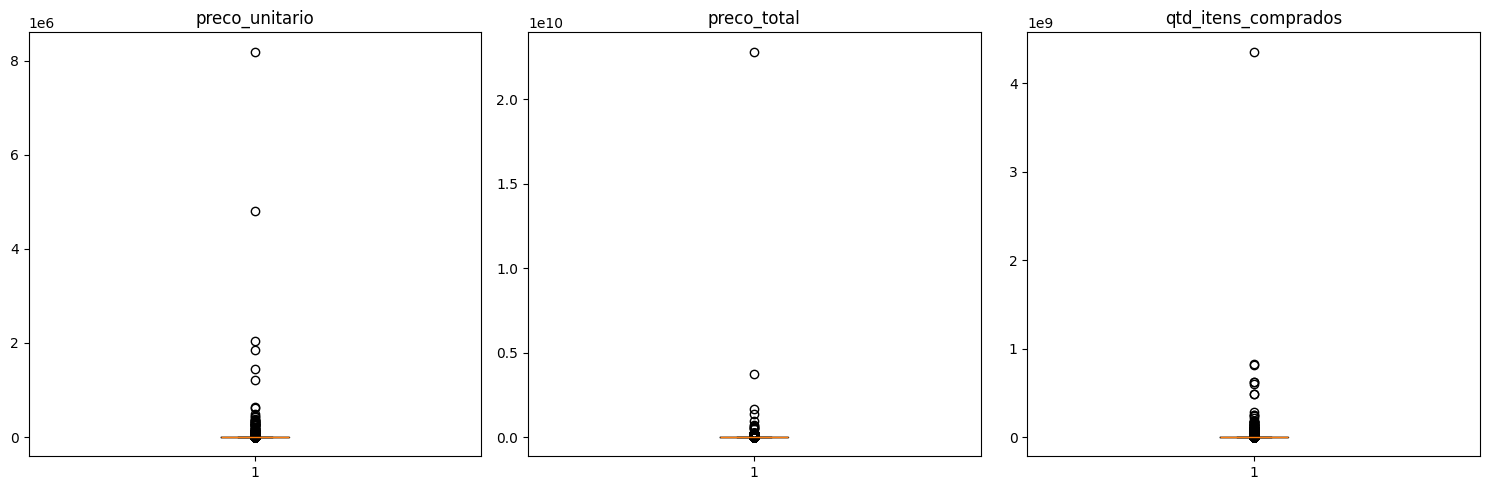

In [15]:
# visualizando outliers com boxplots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['preco_unitario', 'preco_total', 'qtd_itens_comprados']):
    ax.boxplot(df_unificado[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [16]:
# verificando a presença de outliers utilizando o método do IQR (Interquartile Range)
def detectar_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    print(f"{coluna}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    print(f"  Limites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    return outliers

outliers_preco_unit = detectar_outliers_iqr(df_unificado, 'preco_unitario')
outliers_preco_total = detectar_outliers_iqr(df_unificado, 'preco_total')
outliers_qtd = detectar_outliers_iqr(df_unificado, 'qtd_itens_comprados')

preco_unitario: 47654 outliers (13.91%)
  Limites: [-9.87, 17.40]
preco_total: 52006 outliers (15.18%)
  Limites: [-17750.00, 31450.00]
qtd_itens_comprados: 58503 outliers (17.07%)
  Limites: [-17375.00, 29625.00]


In [17]:
# salvando o dataframe tratado em um novo arquivo CSV
df_unificado.to_csv('../dados/BPS_20_26_MariaHelena_tratado.csv', sep=';', index=False, encoding='utf-8')

# verificando se os dados foram salvos corretamente
print(f"O Dataframe foi salvo com sucesso.")


O Dataframe foi salvo com sucesso.
